***In order to subimt your assigment, please follow these instructions carefully:***

1. It's recommended to run this notebook in the DOORS platform, or, if you know what you're doing (or need another module, though you can also locally install modules with `pip install`, but beware that they might disappear). (It is not necessary to install new packages, but you can if you find them useful for the completion of this assignment.
2. Once you are done with the assignment, make sure to restart the Kernel and run all to ensure that eveything runs in sequence and that you don't have errors.
3. When you're done with the steps, save the notebook and also save the notebook as PDF (File > Save/Export (depnding on the Jupyter version) > PDF). Upload the PDF in UNESS. You can also upload the ipynb once you've saved it (you can get it from File > Download).

***Please don't forget to tell me who you are:***

**NAME: Thanh-Phuong VO**

**EMAIL: Thanh-Phuong.Vo@etu.univ-grenoble-alpes.fr; 0001thanhphuong@gmail.com**


Notes:
- While doing this assigment, try also to go a bit "beyond" what's being asked, i.e. show the process which you follow and how you approach the problem.
- Look online for ways to get what you want from insights (i.e. how to check a model's performance while training)
- Feel free to check other tutorials and assignments to get ideas for algorithms
- If you copy something from somewhere, you should reference it properly and explain what it does (also for your code)

# Assignment 1 - Supervised Learning - Classification

The purpose of this assignment is to use machine learning algorithms to classify data points which have a **label**. We will classify the dataset below, which consists in 4 clusters. For this assignment, your objective is to try out 2-3 classification methods, justifying why you picked up these methods and fine-tuning a bit their parameters.

The dataset is produced with the first two block of code (below): the first one imports the necessary modules and the second generates the dataset `X, y`.


In [1]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline

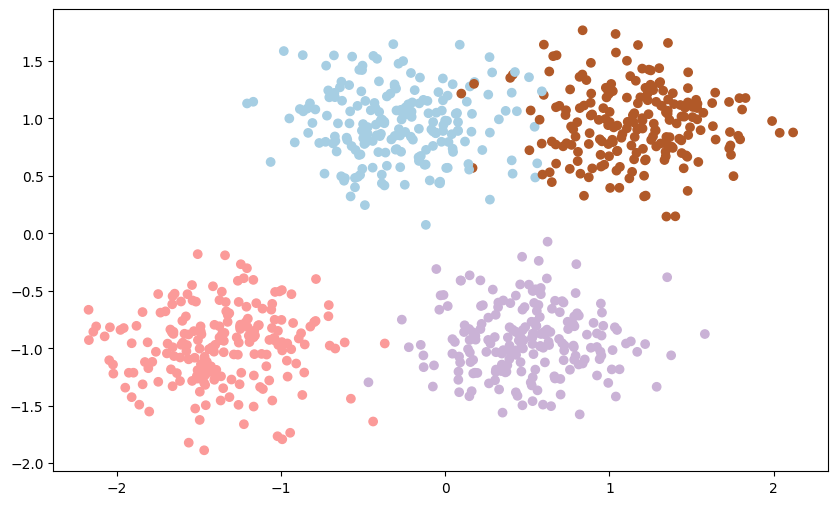

In [2]:
centers = [[0.5, 2], [-1, -1], [1.5, -1], [2.5, 2]] #Create dataset
X, y = make_blobs(n_samples=800, centers=centers,
                  cluster_std=0.5, random_state=0) #Normalize the values
X = StandardScaler().fit_transform(X)

plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='Paired')

## Testing your classifier

The function below can be used to test the classifier: it shows the [confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) and returns the fraction of points that have been correctly classified.

In [3]:
def analyse_classifier(model, X, y):
  yPred = model.predict(X)
  from sklearn.metrics import confusion_matrix
  cm = confusion_matrix(y, yPred)
  import matplotlib.pyplot as plt
  %matplotlib inline
  import seaborn as sns; sns.set()
  sns.heatmap(cm.T, square=True, annot=True, fmt='d', cbar=False)
  plt.xlabel('true label')
  plt.ylabel('predicted label');
  nTotal = len(y)
  nCorrect = np.count_nonzero(y-yPred==0)
  print(f"Correcly classified {nCorrect} out of {nTotal} points ({nCorrect/nTotal*100}%)")

As an example to get started, have a look at the code below, and answer the following questions.

*Suggestions:*
- *to put your answer, edit the text and put it between the two groups of `**` which make the text in bold (please preserve `Answer:` part).*
- *if you need to use code (you'll often need to), just create new Text and Code blocks as needed, even multiple, below. Do not forget to properly comment things in the text part as well as in the code using `# This is a comment`*

Questions (note: there's space to answer below)
- Q1 [2pts] What is the classified being trained? What does it do? What do the options mean?
- Q2 [2pts] How well does the classifier perform? Can we do better? How?
- Q3 [2pts] Can you describe the algorithm another way? Making use of two pieces ?


Correcly classified 790 out of 800 points (98.75%)


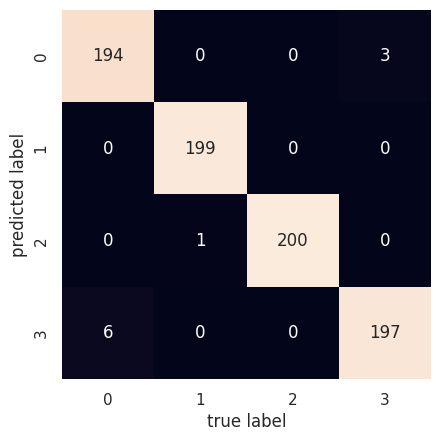

In [4]:
from sklearn.ensemble import RandomForestClassifier
# Instantiating a random forest classifier
model_1 = RandomForestClassifier(n_estimators=1, random_state=0)
# Fitting the model to our datapoints
model_1.fit(X, y)
# Evaluate the classifier
analyse_classifier(model_1, X, y)

Q1 [2pts] What is the classified being trained? What does it do? What do the options mean?

**Answer:**
- The classified being trained is RandomForestClassifier.
- This classifier is  a ensemble learning model that builds multiple decision trees and aggregates their predictions using majority voting.**
- The meanings of options:
    - n_estimators=1: The number of trees in the forest; here, only one tree is used, making the model a single decision tree.**
    - random_state=0: A fixed seed ensuring reproducibility of the model’s randomness. Controls both the randomness of the bootstrapping of the samples used when building trees (if bootstrap=True) and the sampling of the features to consider when looking for the best split at each node (if max_features < n_features).

Q2 [2pts] How well does the classifier perform? Can we do better? How?

**Answer:**
- The classifier correctly predicts 790 out of 800 samples (98.75%), and the confusion matrix shows that misclassifications are concentrated mainly in one class (6 points in class 0 were predicted in class 3).
- We can improve performance by:
    - Increasing the number of trees (n_estimators) to stabilize predictions
    - Tuning hyperparameters (e.g., max_depth, min_samples_leaf)
    - Trying alternative algorithms such as SVM, KNN, or Gradient Boosting.

First attempt at improvement of the classifier used above.

Correcly classified 800 out of 800 points (100.0%)


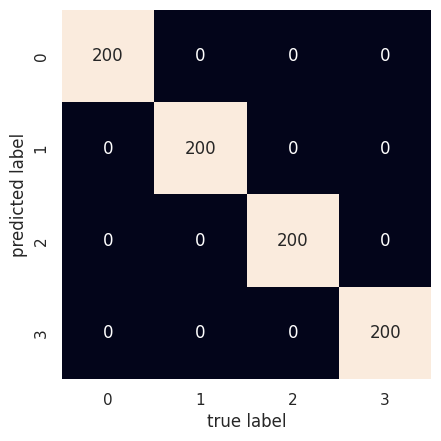

In [5]:
# Enter your code here and call analyse_classifier (by un-commenting the lines below and filling them in as appropriate)
from sklearn.ensemble import RandomForestClassifier
model_2 = RandomForestClassifier(n_estimators=7, random_state=3)
model_2.fit(X, y)
analyse_classifier(model_2, X, y)

Another attempt



Correcly classified 800 out of 800 points (100.0%)


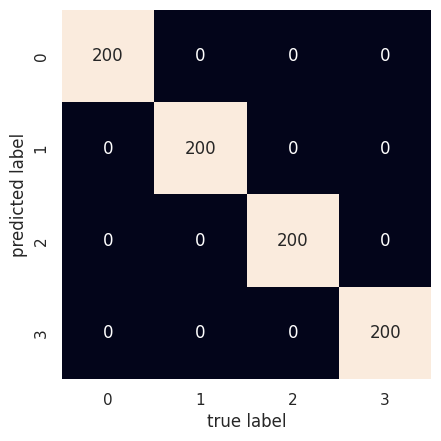

In [6]:
# Enter your code here and call analyse_classifier (by un-commenting the line below)
from sklearn.neighbors import KNeighborsClassifier
model_3 = KNeighborsClassifier(n_neighbors=1, weights='distance')
model_3.fit(X, y)
analyse_classifier(model_3, X, y)

Q3 [2pts] Can you describe the algorithm another way? Making explicit of the two pieces (algorithms) used ?

**Answer:**

Random Forest operates using two main sources of randomness:
1. Bootstrap Sampling
    - Each tree in the ensemble is built from a sample drawn with replacement from the training set.
    - This creates different datasets for different trees, decorrelating their errors.
2. Random Feature Selection
    - During the construction of each tree in the forest, a random subset of the features is considered (controlled by *max_features*).
    - This prevents trees from all focusing on the same dominant features, further reducing correlation.

After all trees are built, predictions are combined by majority vote (classification) or mean (regression).

Because the individual trees are diverse and have uncorrelated errors, the final ensemble has lower variance compared to a single decision tree.

Correcly classified 790 out of 800 points (98.75%)


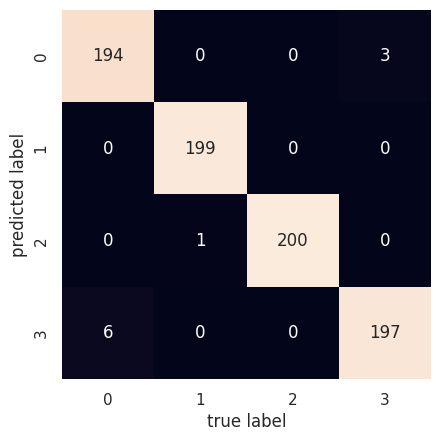

In [7]:
# Enter your code here
from sklearn.ensemble import RandomForestClassifier
model_4 = RandomForestClassifier(n_estimators=1, max_features=1, bootstrap=True, random_state=0)
model_4.fit(X, y)
analyse_classifier(model_4, X, y)

## Properly using the dataset for machine learning

Q4 [2pts] What can you tell me about the way we've been using the dataset so far ? Is it appropriate ?

**Answer:**
No, it is not appropriate. The way they use the dataset as the entire dataset for both training and testing, which leads to an over optimistic accuracy estimate and prevents meaningful evaluation of generalization. A proper workflow is to split the dataset into train/test or using cross-validation.

Q5 [2pts]  What can you tell me about the multiple ways one can split the dataset to train machine learning algorithms ?

**Answer:**
Some of methods to split the dataset are:
- Split the dataset into train/test (eg. with the ratio of 80/20,...)
- K-fold cross-validation:split the data into k folds and train the model k times, each time testing on a different fold, to obtain a more reliable performance estimate.
- Leave-one-out cross-validation (LOOCV): train on all samples except one per iteration, test on the left-out sample, and repeat this for every sample to maximize data usage
- Stratified splitting: split the data while maintaining the same class distribution in both train and test sets to avoid biased evaluation.


Q6 [2pts] When a small amount of data is available, are there alternative methods that can be used, rather than splitting the dataset? Please explain.

**Answer:**
With small datasets, splitting may waste valuable training data. Alternative methods that can be used include:
- K-fold cross-validation: because each sample is used for training in (k–1) folds, increasing the effective amount of training data.
- Leave-one-out cross-Validation (LOOCV): because the model is always trained on almost the entire dataset.
- Bootstrapping: because it generates many synthetic “pseudo-datasets,” allowing us to estimate model stability and variability without holding out a fixed test set.
These methods allow using most or all data for learning while still producing valid performance estimates.


In the cases below, the example code doesn't take into account any splitting. ***Please split the data accordingly (using examples from tutorials or from the internet), and don't forget to adjust the code examples accordingly, so as to fit and evaluate the model on different datasets.***

Correcly classified 154 out of 160 points (96.25%)


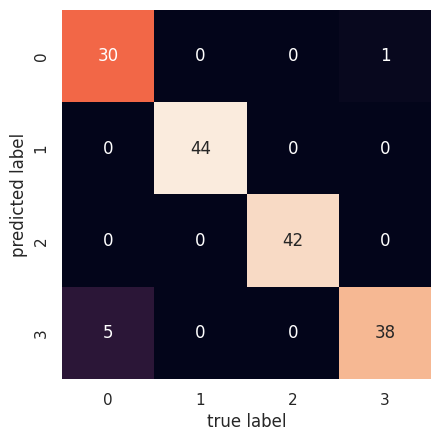

In [8]:
# Code to split the dataset appropriately
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

# from sklearn.model_selection import KFold
# kf = KFold(n_splits=5, shuffle=True, random_state=0)
# for train_idx, test_idx in kf.split(X):
#     X_train, X_test = X[train_idx], X[test_idx]
#     y_train, y_test = y[train_idx], y[test_idx]

# from sklearn.model_selection import StratifiedKFold
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
# for train_idx, test_idx in skf.split(X, y):
#     X_train, X_test = X[train_idx], X[test_idx]
#     y_train, y_test = y[train_idx], y[test_idx]

# I compared the result after spliting dataset to the result before splitting dataset.
from sklearn.ensemble import RandomForestClassifier
model_1_split = RandomForestClassifier(n_estimators=1, random_state=0)
model_1_split.fit(X_train, y_train)
analyse_classifier(model_1_split, X_test, y_test)

## Trying out other algorithms

Please try out different algorithms and see whether they perform better or worse, and try to explain why that might be, and whether there's something that can be done to improve the situation.

### Alternative Algorithm #1

Q7 [2pts] Please briefly describe the algorithm, and explain what it attempts to do. If needed, you can create multiple other models with different settings and compare them to explain your thought process.

**Answer:**
A suitable alternative is K-Nearest Neighbors (KNN). KNN is a type of instance-based learning: it does not attempt to construct a general internal model, but simply stores instances of the training data. The optimal choice of the value is highly data-dependent: in general a larger suppresses the effects of noise, but makes the classification boundaries less distinct.
KNN classifies a point based on the labels of its k closest neighbors, determined by distance.

Correcly classified 800 out of 800 points (100.0%)


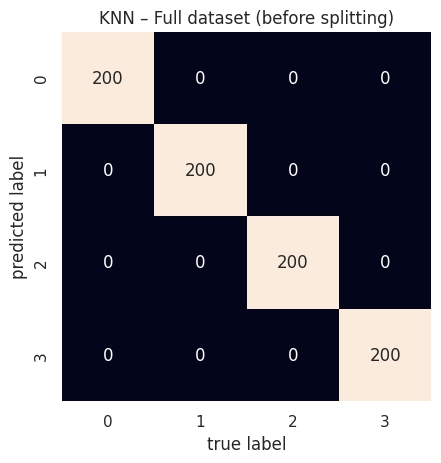

Correcly classified 156 out of 160 points (97.5%)


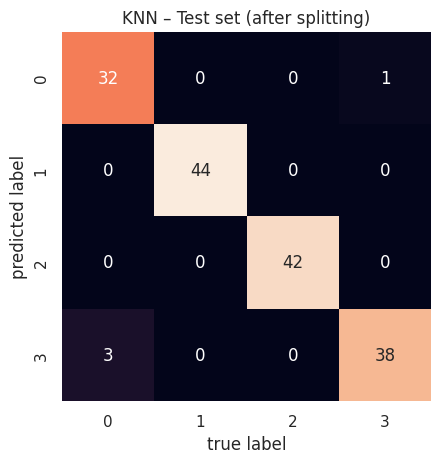

In [9]:
# Enter your code here and call analyse_classifier (by un-commenting the line below)
# Don't forget to fit your model before calling analyse_classifier
from sklearn.neighbors import KNeighborsClassifier
model_5 = KNeighborsClassifier(n_neighbors=1, weights='distance')
model_5.fit(X, y)
analyse_classifier(model_5, X, y)
plt.title("KNN – Full dataset (before splitting)")
plt.show()

model_5_s = KNeighborsClassifier(n_neighbors=3, weights='distance')
model_5_s.fit(X_train, y_train)
analyse_classifier(model_5_s, X_test, y_test)
plt.title("KNN – Test set (after splitting)")
plt.show()

### Alternative Algorithm #2

Q8 [2pts] Please briefly describe the algorithm, and explain what it attempts to do. If needed, you can create multiple other models with different settings and compare them to explain your thought process.

**Answer:**
- As this dataset is clearly separable. The SVM can be an alternative algorithm.
- SVM is a supervised learning method that aims to find the hyperplane (optimal decision boundary) that maximizes the margin between different classes. Only a subset of training points, called support vectors, contributes to defining this boundary, making the method memory efficient.
- SVMs are particularly effective in low- to high-dimensional spaces and perform well when the classes are clearly separable. By using kernel functions (e.g., linear or RBF), SVM can model both linear and non-linear decision boundaries. Proper choice of the regularization parameter and kernel allows controlling overfitting while maintaining strong generalization performance.

Correcly classified 788 out of 800 points (98.5%)


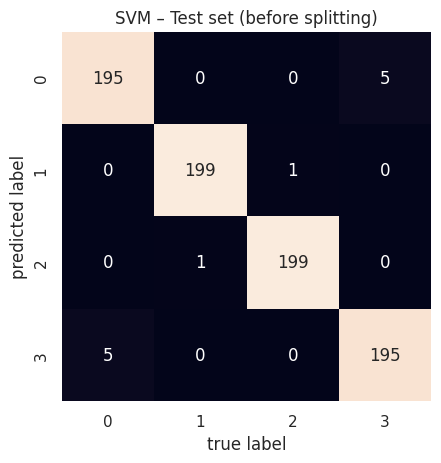

Correcly classified 156 out of 160 points (97.5%)


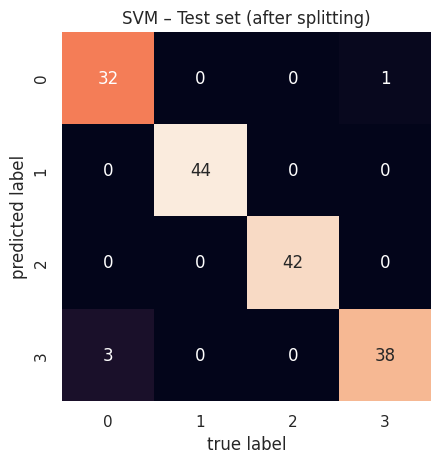

In [10]:
# Enter your code here and call analyse_classifier (by un-commenting the line below)
# Don't forget to fit your model before calling analyse_classifier
from sklearn.svm import SVC
model_6 = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=0)
model_6.fit(X, y)
analyse_classifier(model_6, X, y)
plt.title("SVM – Test set (before splitting)")
plt.show()

model_6_s = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=0)
model_6_s.fit(X_train, y_train)
analyse_classifier(model_6_s, X_test, y_test)
plt.title("SVM – Test set (after splitting)")
plt.show()

### Alternative Algorithm #3

Q9 [2pts] Please briefly describe the algorithm, and explain what it attempts to do. If needed, you can create multiple other models with different settings and compare them to explain your thought process.

**Answer:**
- An alternative algorithm is Gradient Boosting Classifier.
- Gradient Boosting is an ensemble learning method that builds a strong classifier by sequentially combining multiple weak learners, typically shallow decision trees. Each new tree is trained to correct the errors made by the previous ones by minimizing a loss function using gradient descent.
- This approach is effective for structured tabular data and can model complex non-linear decision boundaries. By controlling parameters such as the number of estimators, learning rate, and tree depth, Gradient Boosting achieves a good balance between bias and variance, leading to strong generalization performance on this dataset.

Correcly classified 800 out of 800 points (100.0%)


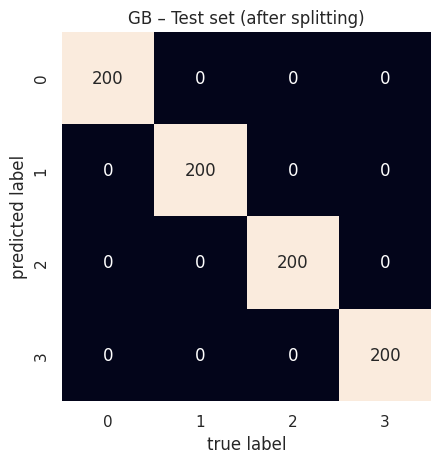

Correcly classified 157 out of 160 points (98.125%)


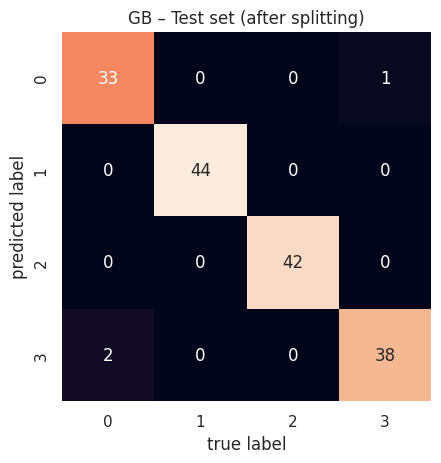

In [11]:
from sklearn.ensemble import GradientBoostingClassifier
model_7 = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=0)
model_7.fit(X, y)
analyse_classifier(model_7, X, y)
plt.title("GB – Test set (after splitting)")
plt.show()

model_7_s = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=0)
model_7_s.fit(X_train, y_train)
analyse_classifier(model_7_s, X_test, y_test)
plt.title("GB – Test set (after splitting)")
plt.show()

## Handling small datasets

Q10 [2pts] Above, we discussed how to handle small datasets. Assuming `X` is a small dataset, please show me how to use a method that can use it in full, yet remain safe in terms of implementation.
The recommended approach is K-Fold Cross-Validation, which splits the data into k folds, trains on k−1 folds, and tests on the remaining fold.
This allows using the full dataset for training, while still providing an unbiased estimate of model performance.

Correcly classified 79 out of 80 points (98.75%)


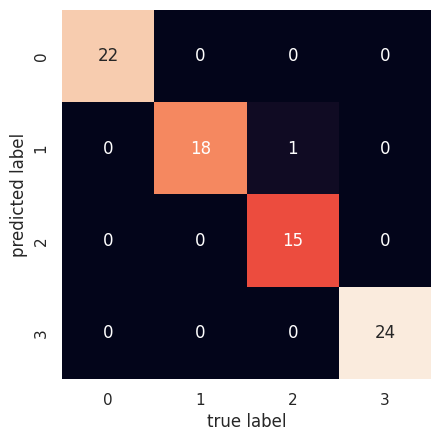

In [12]:
# Handling of small datasets with KFold
from sklearn.model_selection import KFold
kf = KFold(n_splits=10, shuffle=True, random_state=0)
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

from sklearn.ensemble import RandomForestClassifier
model_1_kfold = RandomForestClassifier(n_estimators=1, random_state=0)
model_1_kfold.fit(X_train, y_train)
analyse_classifier(model_1_kfold, X_test, y_test)

Correcly classified 80 out of 80 points (100.0%)


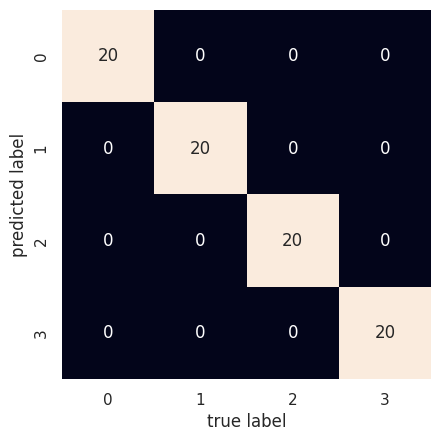

In [13]:
# Handling of small datasets with StratifiedKFold
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

from sklearn.ensemble import RandomForestClassifier
model_1_skfold = RandomForestClassifier(n_estimators=1, random_state=0)
model_1_skfold.fit(X_train, y_train)
analyse_classifier(model_1_skfold, X_test, y_test)

## Assuming the dataset is not labeled

Let's assume that you were given ONLY `X`, i.e. you don't know the *label* of these data points.

Q11 [2pts] Can you use the same machine learning methods? What do you need to change?

**Answer:**
No. We cannot use the same ML methods, because supervised methods such as Random Forest, SVM, or KNN require labels.
With unlabeled data, it need to change to unsupervised learning, where these algorithms group data by similarity rather than learned labels.
Some appropriate methods include: k-means clustering, DBSCAN.

Q12 [3pts] Can you pick a model that you could use if only given `X` ? Please implement one version (in the block below).

**Answer:**
A model that can be used if only given `X` is K-means clustering. Because it is an unsupervised algorithm that groups data based on the structure and distances within X, without requiring any labels.

In [14]:
# Code block to implement model that would group points without knowing their label
from sklearn.cluster import KMeans
model_8 = KMeans(n_clusters=4, n_init='auto')
model_8.fit(X)

KMeans(n_clusters=4, n_init='auto')

Let's check how your algorithm performs (running the code below). Are you happy with the result?

**Answer:**
Yes, I am happy with the result. Because:
- K-means clearly identifies the four clusters present in the dataset.
- The visualization shows that each group of points is assigned to a distinct cluster with well-separated boundaries.
- The cluster centers are positioned at the middle of each cluster, meaning the algorithm successfully captured the underlying structure of the data.

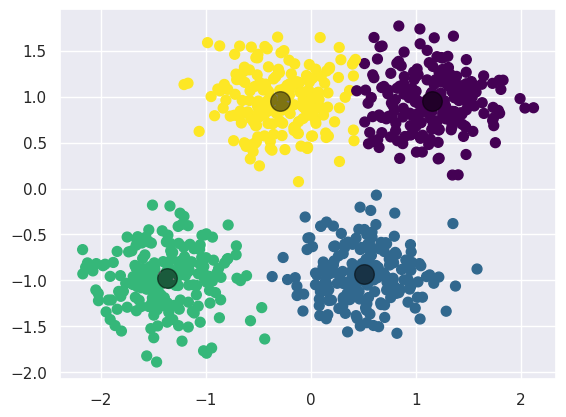

In [15]:
def show_model_prediction(model, X):
  labels = model_8.fit_predict(X)
  plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

# Uncomment to plot
show_model_prediction(model_8, X)

centers = model_8.cluster_centers_ # Obtain cluster centers
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

# Wrapping up

*Note: use this space for thoughts; this part is not part of the mark (unless you don't fill it at all).*

What did you take out from this?

**Answer:**
This assignment help me understand the difference of ML algorithms on the same dataset and the choices strongly affect our interpretation of performance.
Some understandings I learned from:

**1. The supervised algorithms**:
- Tree-based ensembles (random forest, gradient boosting) achieved strong results by modeling non-linear decision boundaries:
    - Random Forest mainly reduces variance through averaging independent trees
    - Gradient Boosting reduces bias by correcting errors sequentially.
- KNN performed well due to the low dimensionality and clear cluster structure of this dataset, but its performance depends strongly on distance metrics and data scaling.
- SVM provided robust performance by maximizing class margins and demonstrated strong generalization when the data is well separated.

**2. The importance of proper data splitting**:
- Evaluating models on the full dataset leads to overly optimistic results, while train/test splitting provides a more realistic estimate of generalization.
- I tried the stratified splitting that gave the high accuracy than non-stratified splitting. This proved the importance to preserve class proportions, avoiding biased evaluations.
- For small datasets, k-fold and stratified k-fold cross-validation offered more reliable performance estimates by using all samples for both training and validation across folds.

**3. The unsupervised algorithm**:
- K-means clustering illustrated a different learning paradigm. This scenario highlights the evaluation relies on structural coherence and visualization rather than classification accuracy. That's why unsupervised learning is essential when annotation is unavailable.

*I would greatly appreciate any feedback you may have on this assignment, as it would help me improve in future work!*